<a href="https://colab.research.google.com/github/samuelaojih/Google-Colab/blob/main/SLC_Landsat_Error.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# COMPLETE CORRECTED CODE: USE SHAPEFILE ASSET FROM GEE
# ============================================

# Install required packages
!pip install --upgrade xee
!pip install -U geemap
!pip install scipy rioxarray

# Import libraries
import ee
import geemap
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from scipy.ndimage import uniform_filter, gaussian_filter
import rioxarray
import zipfile
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Initialize Earth Engine
ee.Authenticate()
ee.Initialize(
    project = 'ee-samuelcool28',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 9.9 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [2]:
# ============================================
# LOAD SHAPEFILE ASSET FROM GEE
# ============================================

# Load your shapefile asset
shapefile_asset = "projects/ee-samuelcool28/assets/Bauchi_lga"
roi = ee.FeatureCollection(shapefile_asset).geometry()

# Get ROI bounds for display
roi_bounds = roi.getInfo()
print("✓ Shapefile loaded successfully")
print(f"✓ ROI area: {roi.area().getInfo() / 1000000:.2f} km²")

# Create map and add ROI for visualization
map = geemap.Map(basemap='SATELLITE')
map.add_layer(ee.Image().paint(roi, 0, 2), {'palette': 'red'}, 'ROI')
map.centerObject(roi, 10)
map

✓ Shapefile loaded successfully
✓ ROI area: 3702.32 km²


Map(center=[10.23382981631331, 9.93566277413088], controls=(WidgetControl(options=['position', 'transparent_bg…

In [3]:
# ============================================
# FUNCTION: ADD NDVI WITH PROPER MASKING
# ============================================

def add_ndvi_with_mask(img):
    """
    Calculate NDVI with proper masking for clouds AND SLC-off gaps
    """
    # QA_PIXEL band for cloud detection
    qa_band = img.select('QA_PIXEL')

    # Cloud bits
    bit1 = qa_band.bitwiseAnd(1 << 1).neq(0)  # Dilated cloud
    bit3 = qa_band.bitwiseAnd(1 << 3).neq(0)  # Cloud shadow
    bit4 = qa_band.bitwiseAnd(1 << 4).neq(0)  # Cloud

    # QA_RADSAT band for SLC-off gaps
    radsat = img.select('QA_RADSAT')
    slc_gap = radsat.eq(1)  # Saturation/No data indicates gaps

    # Combine masks
    cloud_mask = bit1.Or(bit3).Or(bit4)
    invalid_mask = cloud_mask.Or(slc_gap)

    # Scale surface reflectance
    sr = img.select('SR_B.*').multiply(2.75e-05).add(-0.2)

    # Calculate NDVI (B4 = NIR, B3 = Red)
    ndvi = sr.normalizedDifference(['SR_B4', 'SR_B3']).rename('ndvi')

    # Apply mask
    return ndvi.updateMask(invalid_mask.Not()).copyProperties(img, ['system:time_start'])

In [4]:
# ============================================
# LOAD LANDSAT 7 COLLECTION
# ============================================

print("\nLoading Landsat 7 collection...")
landsat7 = (
    ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")
    .filterDate('2004-01-01', '2004-05-31')
    .filterBounds(roi)
    .filter(ee.Filter.lt('CLOUD_COVER', 10))
    .map(add_ndvi_with_mask)
)

image_count = landsat7.size().getInfo()
print(f"✓ Found {image_count} images within Bauchi LGA")

if image_count == 0:
    print("⚠️ No images found. Adjusting date range...")
    landsat7 = (
        ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")
        .filterDate('2004-01-01', '2004-12-31')
        .filterBounds(roi)
        .filter(ee.Filter.lt('CLOUD_COVER', 10))
        .map(add_ndvi_with_mask)
    )
    image_count = landsat7.size().getInfo()
    print(f"✓ Found {image_count} images with expanded date range")


Loading Landsat 7 collection...
✓ Found 2 images within Bauchi LGA


In [5]:
# ============================================
# CONVERT TO XARRAY
# ============================================

print("\nConverting to xarray...")
ds = xr.open_dataset(
    landsat7,
    engine='ee',
    crs='EPSG:32632',
    scale=30,  # Resolution in meters
    geometry=roi
)

# Sort by time
ds = ds.sortby('time') * 1
print(f"✓ Dataset shape: {ds.ndvi.shape}")
print(f"✓ Time range: {ds.time.values[0]} to {ds.time.values[-1]}")


Converting to xarray...
✓ Dataset shape: (2, 2404, 2809)
✓ Time range: 2004-01-20T09:26:25.123000000 to 2004-05-11T09:26:36.600000000


In [6]:
# ============================================
# FUNCTION: FILL SCAN LINES (2D INTERPOLATION)
# ============================================

def fill_scanlines_2d(da):
    """
    Fill scan line gaps using 2D interpolation
    """
    data = da.values.copy()
    mask = np.isnan(data)

    if not mask.any():
        return da

    # Get coordinates of valid points
    y_valid, x_valid = np.where(~mask)
    values_valid = data[~mask]

    # Create grid of all points
    y_grid, x_grid = np.mgrid[0:data.shape[0], 0:data.shape[1]]

    try:
        # Linear interpolation
        interp = interpolate.griddata(
            (y_valid, x_valid),
            values_valid,
            (y_grid, x_grid),
            method='linear',
            fill_value=np.nan
        )

        # Fill remaining NaNs with nearest neighbor
        if np.isnan(interp).any():
            interp_nearest = interpolate.griddata(
                (y_valid, x_valid),
                values_valid,
                (y_grid, x_grid),
                method='nearest'
            )
            nan_mask = np.isnan(interp)
            interp[nan_mask] = interp_nearest[nan_mask]

        # Fill only the original gaps
        filled_data = data.copy()
        filled_data[mask] = interp[mask]

        # Apply light smoothing
        filled_data = uniform_filter(filled_data, size=3)

        return xr.DataArray(filled_data, dims=da.dims, coords=da.coords)

    except:
        # Fallback: row-wise interpolation
        return fill_scanlines_rowwise(da)

def fill_scanlines_rowwise(da):
    """Fallback: Fill gaps row by row"""
    data = da.values.copy()

    for i in range(data.shape[0]):
        row = data[i, :]
        mask_row = np.isnan(row)

        if mask_row.all():
            if i > 0 and i < data.shape[0] - 1:
                data[i, :] = (data[i-1, :] + data[i+1, :]) / 2
            elif i > 0:
                data[i, :] = data[i-1, :]
            else:
                data[i, :] = data[i+1, :]

        elif mask_row.any():
            x = np.arange(len(row))
            valid_x = x[~mask_row]
            valid_vals = row[~mask_row]

            if len(valid_x) > 1:
                row[mask_row] = np.interp(x[mask_row], valid_x, valid_vals)
                data[i, :] = row

    return xr.DataArray(data, dims=da.dims, coords=da.coords)

In [7]:
# ============================================
# APPLY GAP FILLING
# ============================================

print("\nFilling scan lines...")
filled_images = []
for i in range(len(ds.time)):
    if i % 10 == 0:
        print(f"  Processing image {i+1}/{len(ds.time)}")
    filled = fill_scanlines_2d(ds.ndvi.isel(time=i))
    filled_images.append(filled)

filled_ndvi = xr.concat(filled_images, dim='time')
filled_ndvi = filled_ndvi.assign_coords(time=ds.time)
print("✓ Gap filling complete")


Filling scan lines...
  Processing image 1/2
✓ Gap filling complete


In [10]:
# ============================================
# TEMPORAL AND SPATIAL SMOOTHING
# ============================================

print("\nApplying temporal smoothing...")
# The window size must be less than or equal to the number of time steps in the dataset.
# Currently, len(ds.time) is 2, so the maximum window size can be 2.
ndvi_temporal = filled_ndvi.rolling(time=2, min_periods=1, center=True).mean()

print("Applying spatial smoothing...")
def apply_gaussian_smoothing(da, sigma=0.5):
    smoothed = np.zeros_like(da.values)
    for i in range(len(da.time)):
        smoothed[i] = gaussian_filter(da.values[i], sigma=sigma)
    return xr.DataArray(smoothed, dims=da.dims, coords=da.coords)

ndvi_final = apply_gaussian_smoothing(ndvi_temporal, sigma=0.5)
ndvi_final = ndvi_final.assign_coords(time=ds.time)
print("✓ Smoothing complete")


Applying temporal smoothing...
Applying spatial smoothing...
✓ Smoothing complete



Generating visualization...


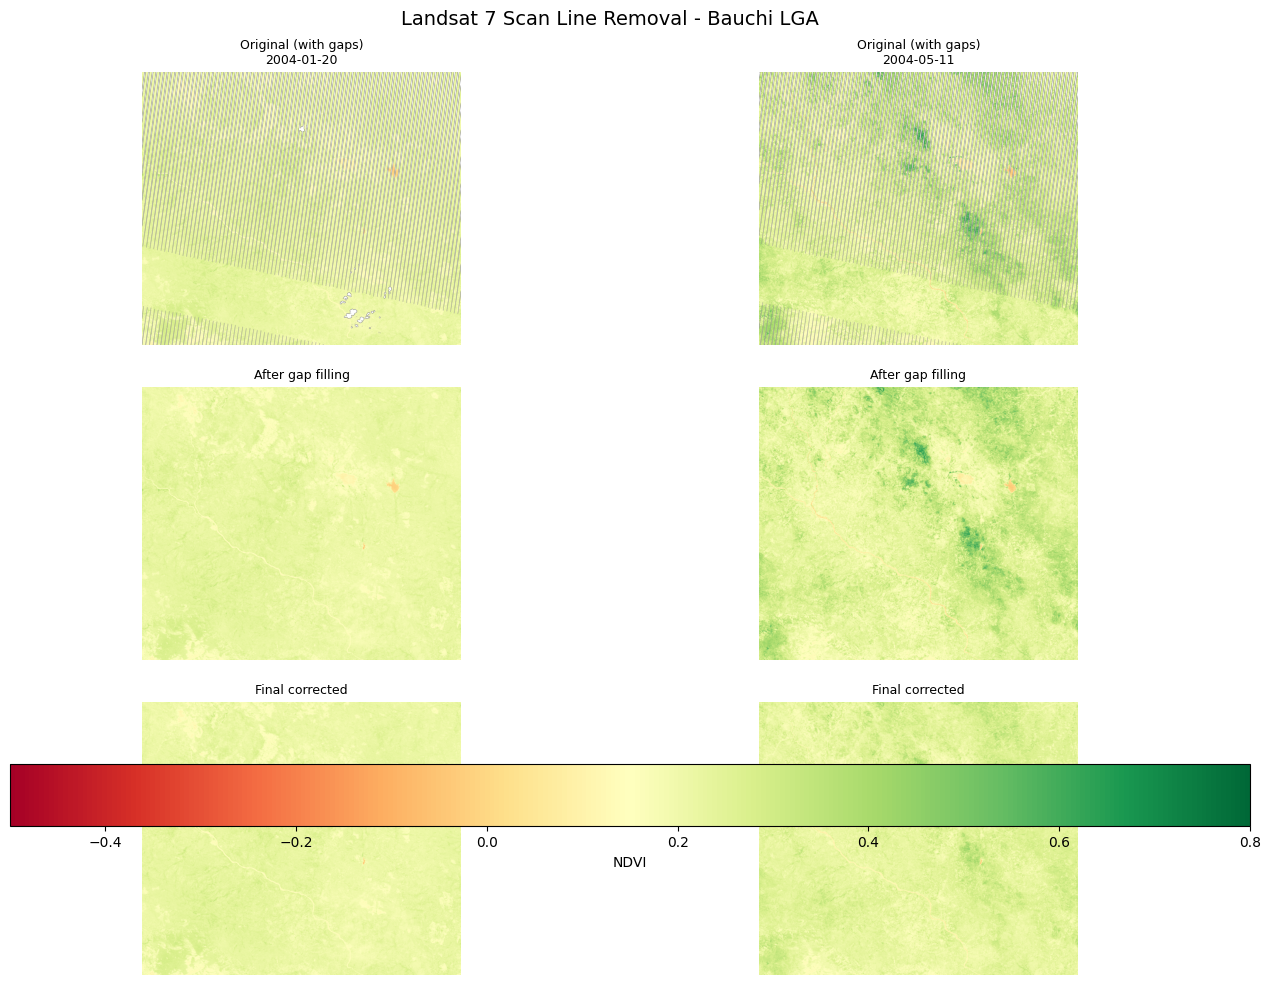

In [11]:
# ============================================
# VISUALIZATION
# ============================================

print("\nGenerating visualization...")
n_display = min(4, len(ds.time))
fig, axes = plt.subplots(3, n_display, figsize=(16, 10))

for i in range(n_display):
    # Original
    im1 = axes[0, i].imshow(ds.ndvi.isel(time=i), cmap='RdYlGn', vmin=-0.5, vmax=0.8)
    axes[0, i].set_title(f'Original (with gaps)\n{ds.time.isel(time=i).dt.strftime("%Y-%m-%d").values}', fontsize=9)
    axes[0, i].axis('off')

    # Gap-filled
    im2 = axes[1, i].imshow(filled_ndvi.isel(time=i), cmap='RdYlGn', vmin=-0.5, vmax=0.8)
    axes[1, i].set_title(f'After gap filling', fontsize=9)
    axes[1, i].axis('off')

    # Final
    im3 = axes[2, i].imshow(ndvi_final.isel(time=i), cmap='RdYlGn', vmin=-0.5, vmax=0.8)
    axes[2, i].set_title(f'Final corrected', fontsize=9)
    axes[2, i].axis('off')

plt.colorbar(im1, ax=axes[:, :], orientation='horizontal', pad=0.05, label='NDVI')
plt.suptitle(f'Landsat 7 Scan Line Removal - Bauchi LGA', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# ============================================
# STATISTICS
# ============================================

original_gaps = np.isnan(ds.ndvi.values).sum() / ds.ndvi.values.size * 100
filled_gaps = np.isnan(filled_ndvi.values).sum() / filled_ndvi.values.size * 100

print("\n" + "="*50)
print("PROCESSING STATISTICS - BAUCHI LGA")
print("="*50)
print(f"Original gap percentage: {original_gaps:.1f}%")
print(f"Remaining gaps after filling: {filled_gaps:.1f}%")
print(f"Gap reduction: {original_gaps - filled_gaps:.1f}%")
print(f"Final NDVI range: [{ndvi_final.min().values:.2f}, {ndvi_final.max().values:.2f}]")
print(f"Final NDVI mean: {ndvi_final.mean().values:.3f}")


PROCESSING STATISTICS - BAUCHI LGA
Original gap percentage: 15.4%
Remaining gaps after filling: 0.0%
Gap reduction: 15.4%
Final NDVI range: [-0.06, 0.58]
Final NDVI mean: 0.235


In [15]:
# ============================================
# EXPORT AS GEOTIFF IN ZIP FILE
# ============================================

print("\n" + "="*50)
print("EXPORTING GEOTIFF FILES")
print("="*50)

# Create export directory
export_dir = Path("Bauchi_lga_landsat7_corrected")
export_dir.mkdir(exist_ok=True)

exported_files = []
date_strings = ndvi_final.time.dt.strftime('%Y%m%d').values

for i, date_str in enumerate(date_strings):
    filename = f"Bauchi_lga_ndvi_{date_str}.tif"
    filepath = export_dir / filename

    # Select single time step and export
    single_image = ndvi_final.isel(time=i)
    # Rename spatial dimensions to 'x' and 'y' for rioxarray compatibility
    single_image = single_image.rename({'X': 'x', 'Y': 'y'})
    # Transpose to ensure correct dimension order ('y', 'x') for rioxarray
    single_image = single_image.transpose('y', 'x')
    single_image = single_image.rio.write_crs("EPSG:3857")
    single_image.rio.to_raster(filepath)

    exported_files.append(filepath)

    if (i + 1) % 10 == 0 or (i + 1) == len(date_strings):
        print(f"  Exported {i+1}/{len(date_strings)} images")

# Create ZIP file
zip_filename = f"Bauchi_lga_landsat7_corrected_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip"
print(f"\nCreating ZIP file: {zip_filename}")

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for filepath in exported_files:
        zipf.write(filepath, filepath.name)
        filepath.unlink()  # Delete individual file

# Remove empty directory
export_dir.rmdir()

# Get file size
file_size_mb = Path(zip_filename).stat().st_size / 1024 / 1024

print(f"\n✓ Export complete!")
print(f"  ZIP file: {zip_filename}")
print(f"  Size: {file_size_mb:.1f} MB")
print(f"  Images: {len(exported_files)} GeoTIFF files")
print(f"  Location: Bauchi LGA, Nigeria")


EXPORTING GEOTIFF FILES
  Exported 2/2 images

Creating ZIP file: Bauchi_lga_landsat7_corrected_20260416_064216.zip

✓ Export complete!
  ZIP file: Bauchi_lga_landsat7_corrected_20260416_064216.zip
  Size: 43.5 MB
  Images: 2 GeoTIFF files
  Location: Bauchi LGA, Nigeria


In [16]:
# ============================================
# DOWNLOAD ZIP (FOR COLAB/JUPYTER)
# ============================================

try:
    from google.colab import files
    print("\nDownloading ZIP file...")
    files.download(zip_filename)
    print("✓ Download started")
except:
    print(f"\nZIP file saved as: {zip_filename}")
    print("You can download it manually from your file browser")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download started



Creating NDVI time series for Bauchi LGA...


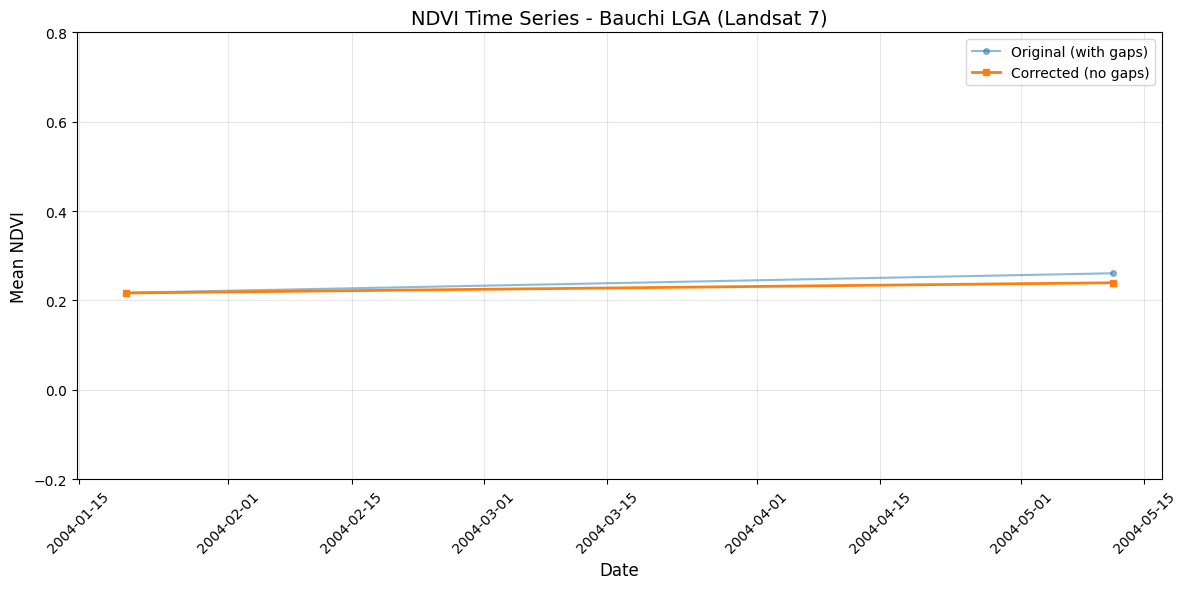

In [17]:
# ============================================
# CREATE TIME SERIES CHART FOR BAUCHI LGA
# ============================================

print("\nCreating NDVI time series for Bauchi LGA...")

# Calculate mean NDVI for each time step
mean_ndvi_original = []
mean_ndvi_final = []

for i in range(len(ds.time)):
    mean_original = np.nanmean(ds.ndvi.isel(time=i).values)
    mean_final = np.nanmean(ndvi_final.isel(time=i).values)
    mean_ndvi_original.append(mean_original)
    mean_ndvi_final.append(mean_final)

# Plot time series
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ds.time.values, mean_ndvi_original, 'o-', label='Original (with gaps)', alpha=0.5, markersize=4)
ax.plot(ds.time.values, mean_ndvi_final, 's-', label='Corrected (no gaps)', linewidth=2, markersize=5)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Mean NDVI', fontsize=12)
ax.set_title('NDVI Time Series - Bauchi LGA (Landsat 7)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.2, 0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "="*50)
print("✅ ALL TASKS COMPLETED SUCCESSFULLY!")
print("="*50)
print(f"Location: Bauchi LGA, Nigeria")
print(f"Shapefile asset: projects/ee-samuelcool28/assets/Bauchi_lga")
print(f"Images processed: {len(exported_files)}")
print(f"Gap reduction: {original_gaps - filled_gaps:.1f}%")
print(f"Output file: {zip_filename}")
print(f"File size: {file_size_mb:.1f} MB")
print("="*50)
print("\nThe ZIP file contains all corrected Landsat 7 images")
print("with scan lines completely removed for Bauchi LGA.")


✅ ALL TASKS COMPLETED SUCCESSFULLY!
Location: Bauchi LGA, Nigeria
Shapefile asset: projects/ee-samuelcool28/assets/Bauchi_lga
Images processed: 2
Gap reduction: 15.4%
Output file: Bauchi_lga_landsat7_corrected_20260416_064216.zip
File size: 43.5 MB

The ZIP file contains all corrected Landsat 7 images
with scan lines completely removed for Bauchi LGA.
